# Wealth Management Dataset — Exploratory Data Analysis

Exploratory analysis of the sample dataset in `data/` ahead of building the AI copilot
described in `PLAN.md`. Covers the structured client/portfolio/transaction data, a
concentration/suitability sanity check, a scan of the unstructured document corpus
(policies, fact sheets, call notes, correspondence, complaints), and a preview of the
golden evaluation workbook.

All data is synthetic (see `data/README.md`).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from pypdf import PdfReader

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (9, 4.5)

DATA = Path("data")
assert DATA.exists(), "run this notebook from the project root"


## 1. Client profiles

One row per client, loaded from `clients_portfolio.json` (KYC/risk attributes; holdings handled separately in section 2).

In [2]:
with open(DATA / "clients_portfolio.json", encoding="utf-8") as f:
    clients_raw = json.load(f)

print(clients_raw["dataset_note"])
print("region focus:", clients_raw["region_focus"])

clients_df = pd.json_normalize(clients_raw["clients"]).drop(columns=["portfolio_holdings"])
clients_df["last_portfolio_review_date"] = pd.to_datetime(clients_df["last_portfolio_review_date"])
print(clients_df.shape)
clients_df.head()


Fictitious client data prepared for a Wealth Management AI Assistant RAG system. No real persons, accounts, or institutions are represented.
region focus: APAC
(15, 22)


,client_id,name,nationality,residency_country,age,occupation,marital_status,net_worth_band,investor_status,base_currency,aum_sgd,risk_profile,risk_score_1_to_10,investment_objective,relationship_manager,servicing_branch,kyc_status,pep_status,source_of_wealth,last_portfolio_review_date,suitability_flag,notes
0,CL001,Tan Wei Ling,Singaporean,Singapore,34,"Tech Entrepreneur (Founder, SaaS startup)",Single,High Net Worth (HNW),Accredited Investor (SFA definition met),SGD,4200000,Aggressive Growth,9,Long-term capital growth; comfortable with hig...,Daniel Koh,Singapore - Marina Bay,Verified - last refreshed 2026-03-18,Not a PEP,Sale of equity stake in previous startup; ongo...,2026-07-02,No mismatch identified - risk profile aligns w...,Client has explicitly requested exposure to co...
1,CL002,Robert Chua,Singaporean,Singapore,68,Retired (former Civil Servant),Married,Mass Affluent,Retail Investor,SGD,850000,Conservative,2,Capital preservation and stable income to supp...,Grace Lim,Singapore - Toa Payoh,Verified - last refreshed 2025-11-05,Not a PEP,"Pension payout, CPF savings, sale of HDB flat ...",2026-01-20,POTENTIAL MISMATCH - Conservative-profile clie...,Flagged for RM review following the 2026-01-20...
2,CL003,Priya Sharma,Indian,Singapore (Employment Pass holder),45,"Physician (Senior Consultant, private hospital)",Married,High Net Worth (HNW),Retail Investor,USD,2100000,Balanced,5,Grow assets moderately while funding children'...,Daniel Koh,Singapore - Marina Bay,Verified - last refreshed 2026-05-12,Not a PEP,"Professional income, inheritance (India), sale...",2026-05-12,No mismatch identified,Client has NRI (Non-Resident Indian) tax statu...
3,CL004,Michael Wong,Hong Kong (Chinese),Hong Kong SAR,52,"Principal, single-family office (manufacturing...",Married,Ultra High Net Worth (UHNW),Professional Investor (per SFO Cap. 571),USD,18500000,Growth,7,Multi-generational wealth growth and preservat...,Cheryl Ng,Hong Kong - Central,Verified - last refreshed 2026-06-30; enhanced...,Not a PEP,Family manufacturing business (three generatio...,2026-06-30,No mismatch identified - qualifies as Professi...,Family office has an Investment Policy Stateme...
4,CL005,Siti Rahman,Indonesian,"Indonesia (Jakarta), banks with Singapore book...",39,"Business Owner (F&B chain, 12 outlets)",Married,High Net Worth (HNW),Accredited Investor (SFA definition met),USD,3300000,Balanced-Aggressive,6,Grow offshore assets for diversification away ...,Cheryl Ng,Singapore - Marina Bay (offshore booking centre),Verified - last refreshed 2026-04-22; source o...,Not a PEP,"F&B business profits, sale of minority stake t...",2026-04-22,No mismatch identified,Cross-border booking centre client (Indonesia ...


In [3]:
clients_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   client_id                   15 non-null     str           
 1   name                        15 non-null     str           
 2   nationality                 15 non-null     str           
 3   residency_country           15 non-null     str           
 4   age                         15 non-null     int64         
 5   occupation                  15 non-null     str           
 6   marital_status              15 non-null     str           
 7   net_worth_band              15 non-null     str           
 8   investor_status             15 non-null     str           
 9   base_currency               15 non-null     str           
 10  aum_sgd                     15 non-null     int64         
 11  risk_profile                15 non-null     str           
 12  risk_sc

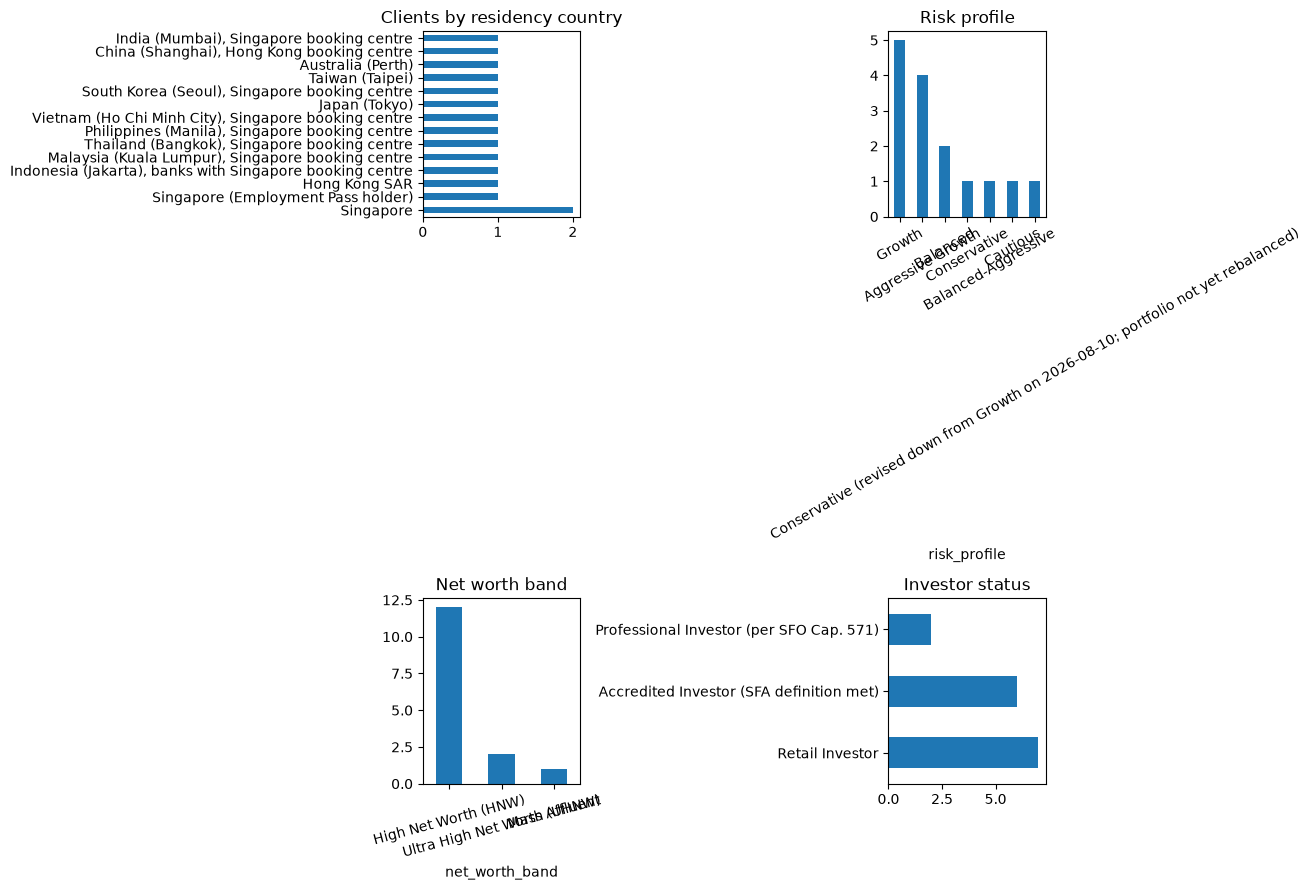

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

clients_df["residency_country"].value_counts().plot.barh(ax=axes[0, 0], title="Clients by residency country")
clients_df["risk_profile"].value_counts().plot.bar(ax=axes[0, 1], title="Risk profile", rot=30)
clients_df["net_worth_band"].value_counts().plot.bar(ax=axes[1, 0], title="Net worth band", rot=15)
clients_df["investor_status"].value_counts().plot.barh(ax=axes[1, 1], title="Investor status")

for ax in axes.flat:
    ax.set_ylabel("")

fig.tight_layout()
plt.show()


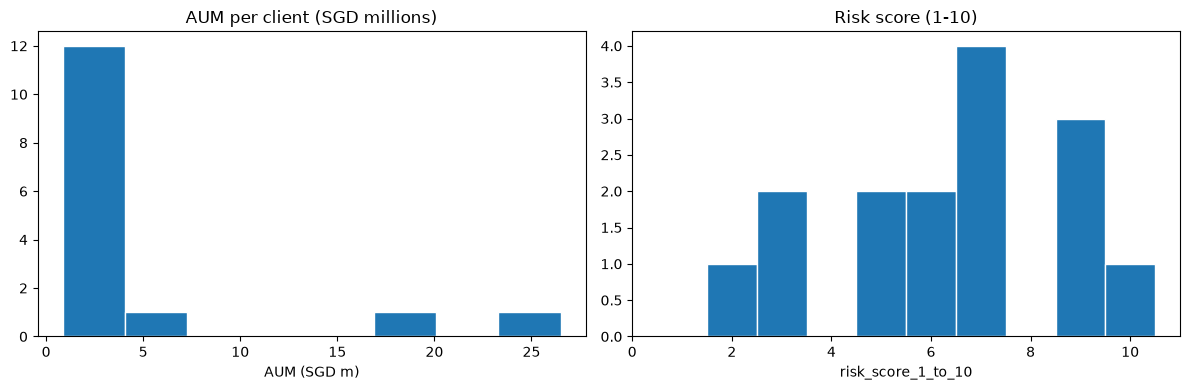

,aum_sgd,risk_score_1_to_10,age
count,1.500000e+01,15.000000,15.000000
mean,5.246667e+06,6.333333,48.333333
std,7.220419e+06,2.410295,10.880301
min,8.500000e+05,2.000000,33.000000
25%,2.025000e+06,5.000000,40.000000
50%,2.900000e+06,7.000000,47.000000
75%,3.525000e+06,8.000000,56.500000
max,2.650000e+07,10.000000,68.000000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(clients_df["aum_sgd"] / 1e6, bins=8, edgecolor="white")
axes[0].set_title("AUM per client (SGD millions)")
axes[0].set_xlabel("AUM (SGD m)")

axes[1].hist(clients_df["risk_score_1_to_10"], bins=range(1, 12), edgecolor="white", align="left")
axes[1].set_title("Risk score (1-10)")
axes[1].set_xlabel("risk_score_1_to_10")

fig.tight_layout()
plt.show()

clients_df[["aum_sgd", "risk_score_1_to_10", "age"]].describe()


In [6]:
clients_df["pep_status"].value_counts()


pep_status
Not a PEP                                                                                                                                                                                                14
PEP-adjacent - former member of a municipal government economic advisory committee (2016-2020); screened, cleared for onboarding with EDD, subject to annual PEP monitoring per POL-KYC-004 Section 5     1
Name: count, dtype: int64

## 2. Portfolio holdings

Flattened one-row-per-holding view from `clients_portfolio.csv` (70 rows).

In [7]:
holdings_df = pd.read_csv(DATA / "clients_portfolio.csv")
print(holdings_df.shape)
holdings_df.head()


(70, 16)


,client_id,name,residency_country,age,net_worth_band,investor_status,risk_profile,risk_score_1_to_10,aum_sgd,relationship_manager,suitability_flag,product_name,asset_class,allocation_pct,value_sgd,holding_currency
0,CL001,Tan Wei Ling,Singapore,34,High Net Worth (HNW),Accredited Investor (SFA definition met),Aggressive Growth,9,4200000,Daniel Koh,No mismatch identified - risk profile aligns w...,APEX Global Multi-Asset Autocallable Note Seri...,Structured Product (Exotic/Complex),25,1050000,USD
1,CL001,Tan Wei Ling,Singapore,34,High Net Worth (HNW),Accredited Investor (SFA definition met),Aggressive Growth,9,4200000,Daniel Koh,No mismatch identified - risk profile aligns w...,Pacific Growth Equity Fund,Equity - Regional,35,1470000,USD
2,CL001,Tan Wei Ling,Singapore,34,High Net Worth (HNW),Accredited Investor (SFA definition met),Aggressive Growth,9,4200000,Daniel Koh,No mismatch identified - risk profile aligns w...,Global Technology Innovation Fund,Equity - Sector Thematic,20,840000,USD
3,CL001,Tan Wei Ling,Singapore,34,High Net Worth (HNW),Accredited Investor (SFA definition met),Aggressive Growth,9,4200000,Daniel Koh,No mismatch identified - risk profile aligns w...,APAC Stable Income Money Market Fund,Cash / Money Market,10,420000,SGD
4,CL001,Tan Wei Ling,Singapore,34,High Net Worth (HNW),Accredited Investor (SFA definition met),Aggressive Growth,9,4200000,Daniel Koh,No mismatch identified - risk profile aligns w...,Private Equity Co-Investment Vehicle - Fund IV,Alternative / Private Equity,10,420000,USD


In [8]:
# sanity check: allocations should sum to ~100% per client
alloc_check = holdings_df.groupby("client_id")["allocation_pct"].sum().rename("total_allocation_pct")
alloc_check.describe()


count     15.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: total_allocation_pct, dtype: float64

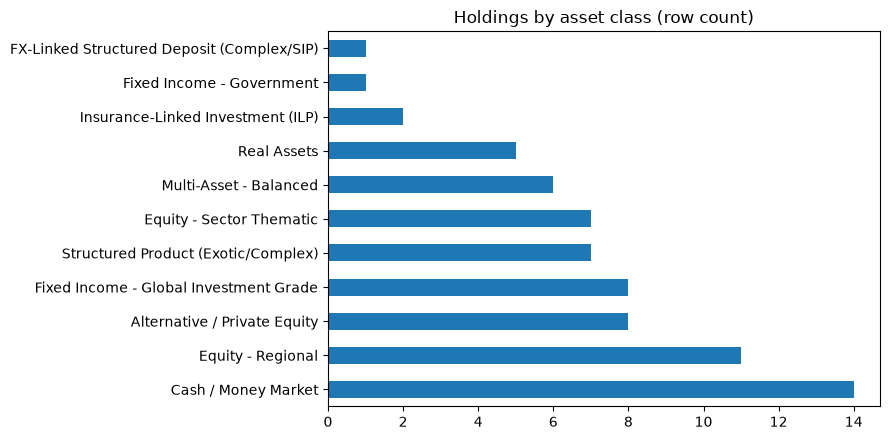

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
holdings_df["asset_class"].value_counts().plot.barh(ax=ax, title="Holdings by asset class (row count)")
ax.set_ylabel("")
fig.tight_layout()
plt.show()


In [10]:
top_products = (
    holdings_df.groupby("product_name")["value_sgd"]
    .agg(total_value_sgd="sum", n_clients="count")
    .sort_values("total_value_sgd", ascending=False)
)
top_products


,total_value_sgd,n_clients
product_name,,
Pacific Growth Equity Fund,19377500,11
Private Equity Co-Investment Vehicle - Fund IV,14087500,8
Global Bond Income Fund,12322500,8
APEX Global Multi-Asset Autocallable Note Series 7,9277500,7
Global Real Estate Income Trust Basket,6830000,5
APAC Stable Income Money Market Fund,6387500,14
Global Technology Innovation Fund,5885000,7
Balanced Income & Growth Fund,3145000,6
Meridian Peak Regular Premium Investment-Linked Policy,885000,2


### Complex-product concentration check

`policy_investment_suitability.pdf` §4 caps a single Complex Product at 20% of a
**Retail Investor's** liquid net worth (Accredited Investors are a worded edge case —
see CL011 in `PLAN.md`). Flag every holding above the 20% threshold, regardless of
investor status, and cross-reference with `investor_status` and the pre-computed
`suitability_flag` to see where automated flagging would need the extra nuance.

In [11]:
# clients_portfolio.csv already carries the client-level fields (investor_status,
# risk_profile, suitability_flag, ...) flattened onto every holding row - no merge needed.
complex_classes = {"Structured Product (Exotic/Complex)", "Alternative / Private Equity"}

flagged = holdings_df[
    holdings_df["asset_class"].isin(complex_classes) & (holdings_df["allocation_pct"] > 20)
][
    ["client_id", "product_name", "asset_class", "allocation_pct", "investor_status", "risk_profile", "suitability_flag"]
].sort_values("allocation_pct", ascending=False)

flagged


,client_id,product_name,asset_class,allocation_pct,investor_status,risk_profile,suitability_flag
46,CL011,APEX Global Multi-Asset Autocallable Note Seri...,Structured Product (Exotic/Complex),35,Accredited Investor (SFA definition met),Aggressive Growth,REVIEW RECOMMENDED - Single Complex Product (a...
0,CL001,APEX Global Multi-Asset Autocallable Note Seri...,Structured Product (Exotic/Complex),25,Accredited Investor (SFA definition met),Aggressive Growth,No mismatch identified - risk profile aligns w...
38,CL009,APEX Global Multi-Asset Autocallable Note Seri...,Structured Product (Exotic/Complex),25,Accredited Investor (SFA definition met),Aggressive Growth,"No mismatch identified - Accredited Investor, ..."
39,CL009,Private Equity Co-Investment Vehicle - Fund IV,Alternative / Private Equity,25,Accredited Investor (SFA definition met),Aggressive Growth,"No mismatch identified - Accredited Investor, ..."
48,CL011,Private Equity Co-Investment Vehicle - Fund IV,Alternative / Private Equity,25,Accredited Investor (SFA definition met),Aggressive Growth,REVIEW RECOMMENDED - Single Complex Product (a...
60,CL014,Private Equity Co-Investment Vehicle - Fund IV,Alternative / Private Equity,25,Professional Investor (per SFO Cap. 571),Growth,No suitability mismatch - holdings align with ...


## 3. Transactions

55-row ledger, Jan-Aug 2026, across all 15 clients.

In [12]:
tx_df = pd.read_csv(DATA / "transactions.csv", parse_dates=["date"])
print(tx_df.shape)
tx_df.head()


(55, 9)


,transaction_id,client_id,date,transaction_type,product_name,amount,currency,status,notes
0,TXN-1001,CL001,2026-02-10,Subscription,APEX Global Multi-Asset Autocallable Note Seri...,1050000,USD,Settled,"Signed risk acknowledgement on file, same date."
1,TXN-1002,CL001,2026-03-01,Subscription,Global Technology Innovation Fund,840000,USD,Settled,NaN
2,TXN-1003,CL001,2026-04-15,Coupon Payment,APEX Global Multi-Asset Autocallable Note Seri...,30188,USD,Settled,Quarterly contingent coupon paid - barrier con...
3,TXN-1004,CL001,2026-05-20,Subscription,Private Equity Co-Investment Vehicle - Fund IV,420000,USD,Settled,Initial capital call funded.
4,TXN-1005,CL001,2026-07-15,Coupon Payment,APEX Global Multi-Asset Autocallable Note Seri...,30188,USD,Settled,NaN


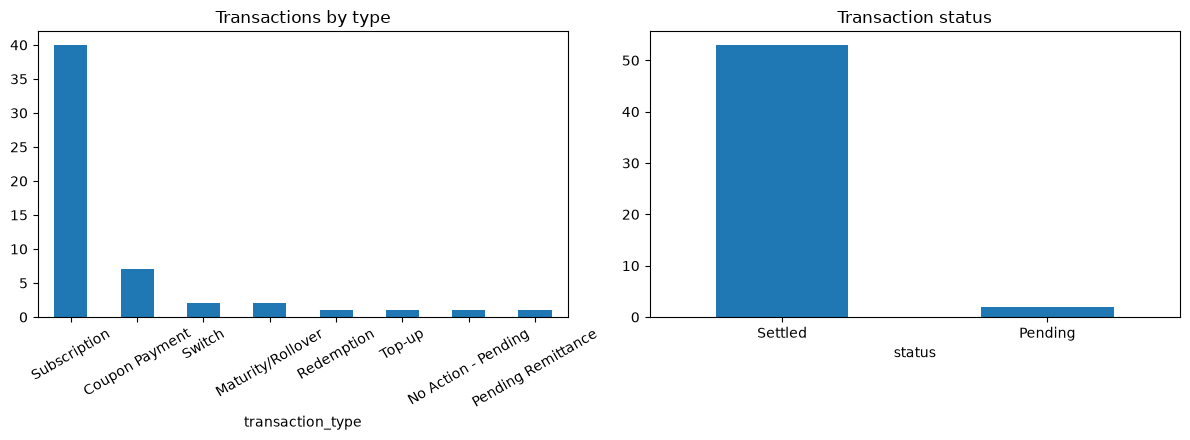

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

tx_df["transaction_type"].value_counts().plot.bar(ax=axes[0], title="Transactions by type", rot=30)
tx_df["status"].value_counts().plot.bar(ax=axes[1], title="Transaction status", rot=0)

fig.tight_layout()
plt.show()


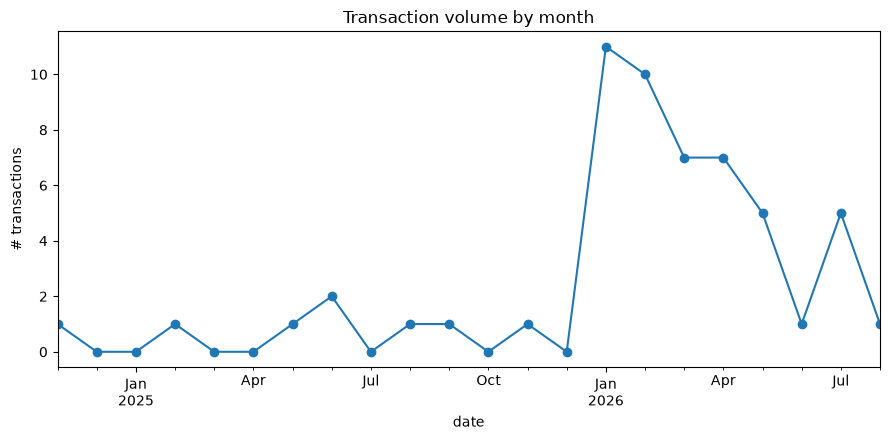

In [14]:
monthly = tx_df.set_index("date").resample("MS").size()

fig, ax = plt.subplots()
monthly.plot(ax=ax, marker="o", title="Transaction volume by month")
ax.set_ylabel("# transactions")
fig.tight_layout()
plt.show()


In [15]:
pending = tx_df[tx_df["status"] == "Pending"]
pending


,transaction_id,client_id,date,transaction_type,product_name,amount,currency,status,notes
46,TXN-1047,CL013,2026-08-11,No Action - Pending,Portfolio Rebalancing (Growth to Conservative),0,USD,Pending,Phased rebalancing plan discussed on call 2026...
54,TXN-1055,CL015,2026-07-25,Pending Remittance,Cash (Investment Top-Up),60000,USD,Pending,Proposed LRS remittance - headroom check in pr...


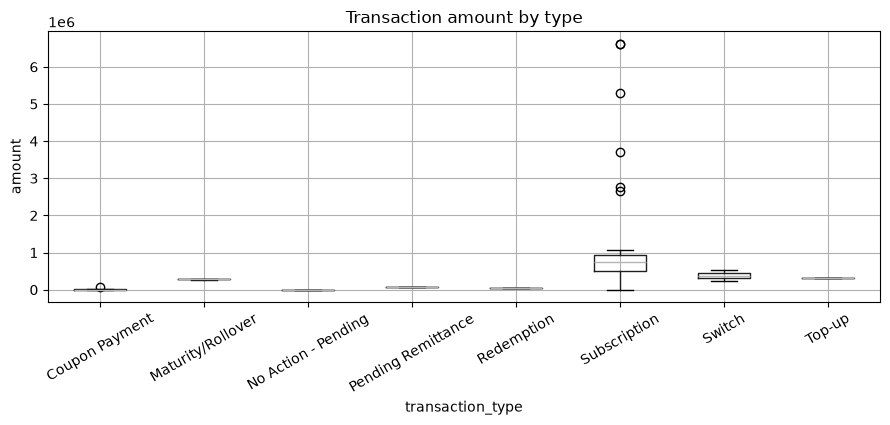

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
tx_df.boxplot(column="amount", by="transaction_type", ax=ax, rot=30)
ax.set_title("Transaction amount by type")
ax.set_ylabel("amount")
plt.suptitle("")
fig.tight_layout()
plt.show()


## 4. Suitability flags

`suitability_flag` is a pre-computed field per client in the dataset — useful as ground truth to check retrieval/reasoning against, not something the copilot should just parrot.

In [17]:
clients_df[["client_id", "name", "risk_profile", "risk_score_1_to_10", "suitability_flag"]]


,client_id,name,risk_profile,risk_score_1_to_10,suitability_flag
0,CL001,Tan Wei Ling,Aggressive Growth,9,No mismatch identified - risk profile aligns w...
1,CL002,Robert Chua,Conservative,2,POTENTIAL MISMATCH - Conservative-profile clie...
2,CL003,Priya Sharma,Balanced,5,No mismatch identified
3,CL004,Michael Wong,Growth,7,No mismatch identified - qualifies as Professi...
4,CL005,Siti Rahman,Balanced-Aggressive,6,No mismatch identified
5,CL006,Ahmad Faisal bin Rahman,Growth,7,No mismatch identified
6,CL007,Nattaya Srisuk,Balanced,5,No mismatch identified
7,CL008,Carlos Bautista,Growth,7,POTENTIAL MISMATCH - Retail Investor holds a D...
8,CL009,Le Thi Mai,Aggressive Growth,9,"No mismatch identified - Accredited Investor, ..."
9,CL010,Kenji Watanabe,Cautious,3,No mismatch identified


## 5. Unstructured document corpus

Quick scan of the PDFs and JSON correspondence that make up the semantic-retrieval
half of the corpus: page/character counts (to gauge chunking granularity) and a short
text preview of each.

In [18]:
pdf_files = sorted(DATA.glob("*.pdf"))

rows = []
for p in pdf_files:
    reader = PdfReader(str(p))
    text = "\n".join((page.extract_text() or "") for page in reader.pages)
    rows.append({
        "file": p.name,
        "n_pages": len(reader.pages),
        "n_chars": len(text),
        "preview": text.strip().replace("\n", " ")[:120],
    })

pdf_overview = pd.DataFrame(rows)
pdf_overview


,file,n_pages,n_chars,preview
0,client_complaint_letters.pdf,3,4786,Client Complaint Letters — Register Extract Me...
1,complex_product_risk_acknowledgement_forms.pdf,2,3176,Complex Product Risk Acknowledgement Form Meri...
2,fund_factsheet_balanced_income_growth.pdf,2,2044,Balanced Income & Growth Fund Fund Fact Sheet ...
3,fund_factsheet_dci_aud_usd.pdf,2,3230,Dual Currency Investment (DCI) — AUD/USD FX-Li...
4,fund_factsheet_exotic_unsafe.pdf,2,4761,APEX Global Multi-Asset Autocallable Note — Se...
5,fund_factsheet_global_bond_income.pdf,2,2138,Global Bond Income Fund Fund Fact Sheet — as a...
6,fund_factsheet_global_reit_basket.pdf,2,2096,Global Real Estate Income Trust Basket Fund Fa...
7,fund_factsheet_global_tech_innovation.pdf,2,2206,Global Technology Innovation Fund Fund Fact Sh...
8,fund_factsheet_ilp_regular_premium.pdf,2,3560,Meridian Peak Regular Premium Investment-Linke...
9,fund_factsheet_pacific_growth_equity.pdf,2,2289,Pacific Growth Equity Fund Fund Fact Sheet — a...


In [19]:
with open(DATA / "client_correspondence.json", encoding="utf-8") as f:
    correspondence = json.load(f)

print(correspondence["dataset_note"])

thread_rows = []
for t in correspondence["email_threads"]:
    dates = [m["date"] for m in t["messages"]]
    thread_rows.append({
        "thread_id": t["thread_id"],
        "subject": t["subject"],
        "related_client_id": t.get("related_client_id"),
        "n_messages": len(t["messages"]),
        "date_range": f"{min(dates)} to {max(dates)}" if dates else None,
    })

correspondence_df = pd.DataFrame(thread_rows)
correspondence_df


Fictitious email correspondence prepared for a Wealth Management AI Assistant RAG system. No real persons or institutions are represented.


,thread_id,subject,related_client_id,n_messages,date_range
0,EML-001,CRS Tax Residency Self-Certification - Follow Up,CL006,3,2026-02-12 to 2026-02-14
1,EML-002,Request to increase Private Equity Fund IV all...,CL009,2,2026-07-22 to 2026-07-23
2,EML-003,Online banking access issue,CL010,3,2026-05-25 to 2026-05-27
3,EML-004,LRS remittance headroom for planned top-up,CL015,3,2026-07-24 to 2026-07-25
4,EML-005,"James Sullivan - retirement, please de-risk po...",CL013,3,2026-08-07 to 2026-08-08
5,EML-006,[Internal] Suitability query - CL002 structure...,CL002,2,2026-02-06 to 2026-02-07
6,EML-007,[Internal] CAR/CKA gap - CL008 Dual Currency I...,CL008,2,2026-04-02 to 2026-04-03


## 6. Golden evaluation dataset

Preview of `golden_dataset_for_RAG_evaluation.xlsx` — the 5 golden Q&A pairs used to score the copilot (see `PLAN.md` §3.4 for the retrieval/generation metrics this workbook computes).

In [20]:
golden_df = pd.read_excel(DATA / "golden_dataset_for_RAG_evaluation.xlsx", sheet_name="Golden Dataset")
golden_df.iloc[:, :6]


,S/N,Topic of the query,Sample query,Citation sources,Relevant paragraph(s) containing supporting evidence,Expected answer
0,EX,EXAMPLE ROW — replace/delete before use,What is the minimum initial investment for the...,fund_factsheet_safe.pdf,Key Facts table: “Minimum Initial Investment: ...,"SGD 10,000 for a retail investor's initial inv..."
1,1,Product Fact Sheet — Risk Rating & Minimum Inv...,What is the Summary Risk Indicator (SRI) ratin...,fund_factsheet_safe.pdf,Risk banner: “SUMMARY RISK INDICATOR — 1 / 7 —...,"The fund has an SRI of 1 out of 7 (low risk), ..."
2,2,Suitability Assessment — Complex Product Mis-Sale,Is Robert Chua's (CL002) holding of the APEX G...,clients_portfolio.json (CL002); policy_investm...,clients_portfolio.json CL002: risk_profile “Co...,"No, this is a suitability concern. Robert Chua..."
3,3,Cross-Border Regulatory Check — India LRS Remi...,How much LRS remittance headroom does Arjun Me...,client_correspondence.json (EML-004); clients_...,client_correspondence.json EML-004 (Daniel Koh...,"No, not as-is. Based on the RM's calculation i..."
4,4,Ambiguous Policy Interpretation — Complex Prod...,Does Park Ji-hoon's (CL011) 35% portfolio allo...,clients_portfolio.json (CL011); policy_investm...,policy_investment_suitability.pdf §4: “No Comp...,This is genuinely ambiguous and the correct an...
5,5,Client Servicing Timeline — Portfolio Rebalanc...,Walk me through what has happened with James S...,client_correspondence.json (EML-005); rm_call_...,client_correspondence.json EML-005 (James Sull...,"No rebalancing has occurred yet, despite the r..."


## Summary

- **15 clients** across 13 APAC/AU markets; risk profiles and AUM are broadly spread, not clustered on one segment.
- **70 holdings** rows; allocations sum to ~100% per client as expected.
- The **concentration check** in §2 surfaces the same edge cases the golden dataset targets (e.g. CL011's Complex Product position), confirming the flagged scenarios are structurally detectable from `clients_portfolio.csv` alone — the harder part is the *policy interpretation* (Retail vs Accredited Investor wording), which requires the text of `policy_investment_suitability.pdf`, not just the numbers.
- **Transactions** are concentrated in Subscriptions/Coupon Payments, with a small number of Pending entries — these pending rows are the ones that matter most for timeline-reconstruction questions (e.g. CL013).
- PDFs are short, text-extractable documents (no OCR needed) — safe to chunk directly from extracted text.
- The golden workbook's 5 queries each require a different combination of structured + unstructured sources, consistent with the multi-source, agentic retrieval approach in `PLAN.md`.
